<a href="https://colab.research.google.com/github/jre29/lecture1uep/blob/regresja/RegLogistycznaIrys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer, load_iris

In [89]:
data = load_iris()
y = data.target
X = data.data

In [90]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head(15)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [91]:
data.data.shape

(150, 4)

In [92]:
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [93]:
data.data.dtype

dtype('float64')

In [94]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [95]:
print(f'Liczba przypadków raka złośliwego: {sum(y == 0)}')

Liczba przypadków raka złośliwego: 50


In [108]:
import matplotlib.pyplot as plt

plt.hist(data.data[:, data.feature_names.tolist().index('mean area')], bins=100)
plt.xlabel('Mean Area')
plt.ylabel('Frequency')
plt.title('Histogram of Mean Area')
plt.grid(True,linestyle='--',alpha=0.4)
plt.show()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

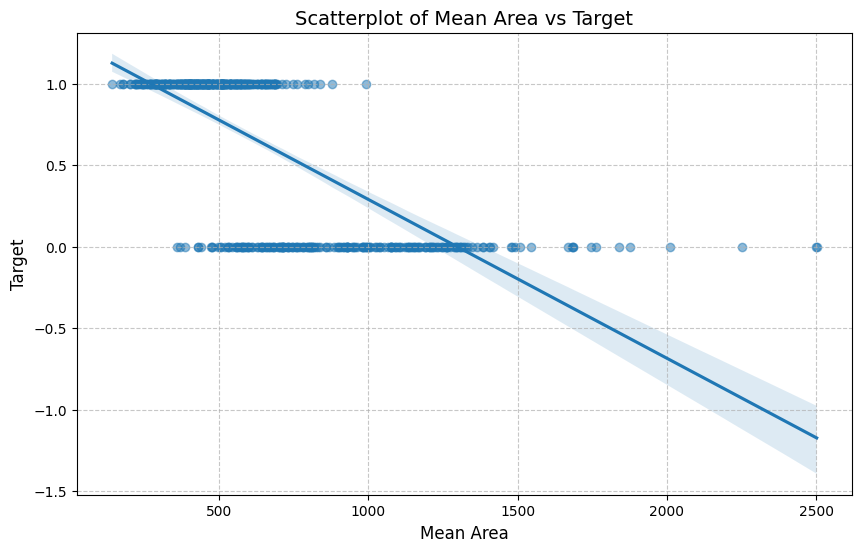

In [80]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='mean area', y='target', data=df, scatter_kws={'alpha': 0.5})
plt.xlabel('Mean Area', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.title('Scatterplot of Mean Area vs Target', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import RocCurveDisplay, roc_curve



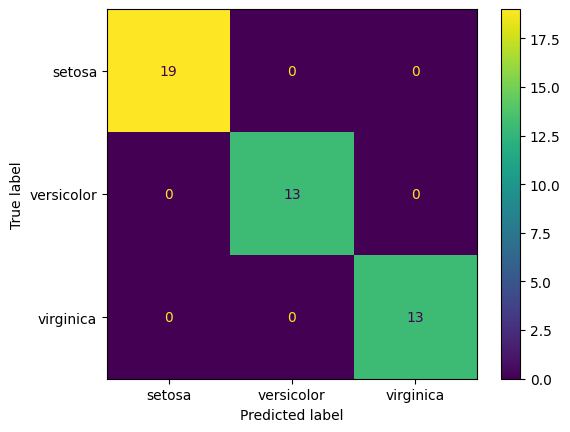

In [109]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.show()



In [110]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)
roc_display.plot()
plt.show()

ValueError: multiclass format is not supported